# 02 — Spiegazioni XAI: SHAP, DiCE, Anchors

Genera le spiegazioni locali per i pazienti selezionati.
Carica il modello e lo split da artifacts/ — non riallena niente.

Prerequisiti: aver eseguito src/prepare_data.py e src/train_model.py.
Prima di committare: Kernel → Restart & Clear Output.

## 0. Carico modello e split

In [1]:
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

model = joblib.load(ROOT / "artifacts" / "model.joblib")
split = joblib.load(ROOT / "artifacts" / "split.joblib")
X_train, X_test = split["X_train"], split["X_test"]
y_train, y_test = split["y_train"], split["y_test"]

pred  = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

# Scelgo i due pazienti di riferimento: uno predetto malato, uno sano
# Questi stessi pazienti verranno usati per tutti e tre i metodi XAI
idx_malato = int(np.where(pred == 1)[0][0])
idx_sano   = int(np.where(pred == 0)[0][0])

print(f"Paziente MALATO  -> indice {idx_malato} | prob={proba[idx_malato]:.2f} | reale={y_test.iloc[idx_malato]}")
print(f"Paziente SANO    -> indice {idx_sano}   | prob={proba[idx_sano]:.2f} | reale={y_test.iloc[idx_sano]}")
print()
print("Feature del paziente MALATO:")
print(X_test.iloc[idx_malato].to_string())

Paziente MALATO  -> indice 0 | prob=0.60 | reale=1
Paziente SANO    -> indice 1   | prob=0.15 | reale=0

Feature del paziente MALATO:
age          58.0
sex           1.0
cp            3.0
trestbps    112.0
chol        230.0
fbs           0.0
restecg       2.0
thalach     165.0
exang         0.0
oldpeak       2.5
slope         2.0
ca            1.0
thal          7.0


In [2]:
"""Tabella descrittiva di un singolo paziente (stimolo per il questionario).

Da incollare in notebooks/02_spiegazioni_xai.ipynb, in una cella DOPO
quella che carica model/split (sezione 0) e PRIMA delle sezioni SHAP/DiCE/Anchors.

Uso:
    tabella_paziente(X_test, idx_malato, titolo="Paziente A")
    tabella_paziente(X_test, idx_malato, salva=ROOT/"artifacts"/"paziente_A.png")

`idx` e' posizionale (come idx_malato / idx_sano gia' in uso, quindi .iloc).
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

label_map = {
    'age':'Età', 'sex':'Sesso', 'cp':'Tipo dolore toracico',
    'trestbps':'Pressione riposo', 'chol':'Colesterolo', 'fbs':'Glicemia',
    'restecg':'ECG riposo', 'thalach':'Freq. cardiaca max', 'exang':'Angina da sforzo',
    'oldpeak':'Depressione ST', 'slope':'Pendenza ST',
    'ca':'Vasi colorati', 'thal':'Test al tallio',
}
value_maps = {
    'sex':     {0:'Femmina', 1:'Maschio'},
    'cp':      {1:'Angina tipica', 2:'Angina atipica', 3:'Dolore non anginoso', 4:'Asintomatico'},
    'fbs':     {0:'Normale (<=120 mg/dL)', 1:'Alta (>120 mg/dL)'},
    'restecg': {0:'Normale', 1:'Anomalia ST-T', 2:'Ipertrofia ventric.'},
    'exang':   {0:'No', 1:'Sì'},
    'slope':   {3:'Discendente', 2:'Piatta', 1:'Ascendente'},
    'thal':    {3:'Normale', 6:'Difetto fisso', 7:'Difetto reversibile'},
}
unita = {
    'age':'anni', 'trestbps':'mmHg', 'chol':'mg/dl',
    'thalach':'bpm', 'oldpeak':'mm', 'ca':'vasi',
}

C_HEADER   = '#1F4E79'
C_RIGA_A   = '#FFFFFF'
C_RIGA_B   = '#F2F5F9'
C_BORDO    = '#B7C6D9'
C_VALORE   = '#1F4E79'
C_TESTO    = '#1A1A1A'


def _fmt_valore(v):
    return str(int(v)) if float(v) == int(v) else f"{float(v):g}"


def _fmt_significato(col, v):
    if col in value_maps:
        return value_maps[col].get(int(v), f"(codice {_fmt_valore(v)})")
    u = unita.get(col)
    return f"{_fmt_valore(v)} {u}" if u else _fmt_valore(v)


def tabella_paziente(X, idx, titolo=None, salva=None, dpi=200,
                     larghezze=(0.34, 0.18, 0.48), altezza_riga=0.42):
    riga = X.iloc[idx]
    righe = [(label_map.get(c, c) + f" ({c})", _fmt_valore(riga[c]), _fmt_significato(c, riga[c]))
             for c in X.columns]

    n = len(righe)
    larghezze = np.array(larghezze, dtype=float)
    larghezze = larghezze / larghezze.sum()
    x = np.concatenate([[0.0], np.cumsum(larghezze)])

    h_tot = altezza_riga * (n + 1)
    fig, ax = plt.subplots(figsize=(8.2, h_tot))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, n + 1)
    ax.axis('off')

    intestazioni = ('Variabile', 'Valore', 'Significato')
    for j, testo in enumerate(intestazioni):
        ax.add_patch(Rectangle((x[j], n), larghezze[j], 1,
                               facecolor=C_HEADER, edgecolor='white', linewidth=1.2))
        ax.text(x[j] + larghezze[j] / 2, n + 0.5, testo, ha='center', va='center',
                color='white', fontsize=10.5, fontweight='bold')

    for i, (var, val, sig) in enumerate(righe):
        y = n - 1 - i
        sfondo = C_RIGA_A if i % 2 == 0 else C_RIGA_B
        for j in range(3):
            ax.add_patch(Rectangle((x[j], y), larghezze[j], 1,
                                   facecolor=sfondo, edgecolor=C_BORDO, linewidth=0.8))
        ax.text(x[0] + 0.012, y + 0.5, var, ha='left', va='center',
                fontsize=9.5, fontweight='bold', color=C_TESTO)
        ax.text(x[1] + larghezze[1] / 2, y + 0.5, val, ha='center', va='center',
                fontsize=9.5, fontweight='bold', color=C_VALORE)
        ax.text(x[2] + 0.012, y + 0.5, sig, ha='left', va='center',
                fontsize=9.5, color=C_TESTO)

    #if titolo:
       # ax.set_title(titolo, fontsize=11.5, fontweight='bold', color=C_HEADER, pad=10)

    plt.tight_layout()
    if salva:
        fig.savefig(salva, dpi=dpi, bbox_inches='tight', facecolor='white')
    return fig

In [3]:
pred  = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

indici_sani   = np.where(pred == 0)[0]
indici_malati = np.where(pred == 1)[0]

print(f"Predetti SANI   ({len(indici_sani)}):   {indici_sani}")
print(f"Predetti MALATI ({len(indici_malati)}): {indici_malati}")

Predetti SANI   (35):   [ 1  2  3  4  7  9 10 14 16 17 19 20 22 23 27 28 31 32 33 35 39 41 42 46
 47 48 49 50 51 52 53 54 55 56 57]
Predetti MALATI (26): [ 0  5  6  8 11 12 13 15 18 21 24 25 26 29 30 34 36 37 38 40 43 44 45 58
 59 60]


idx  21 | predetto MALATO | prob. malattia 0.95 | reale 1
idx  24 | predetto MALATO | prob. malattia 0.93 | reale 1


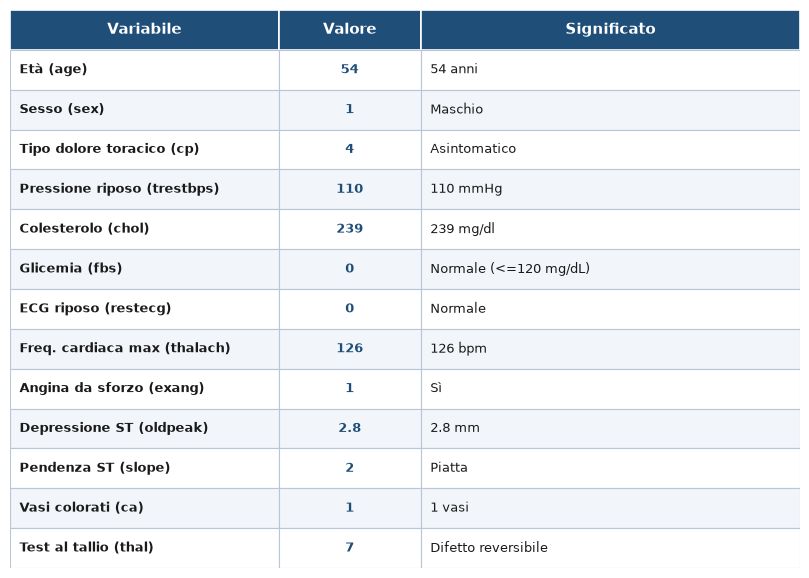

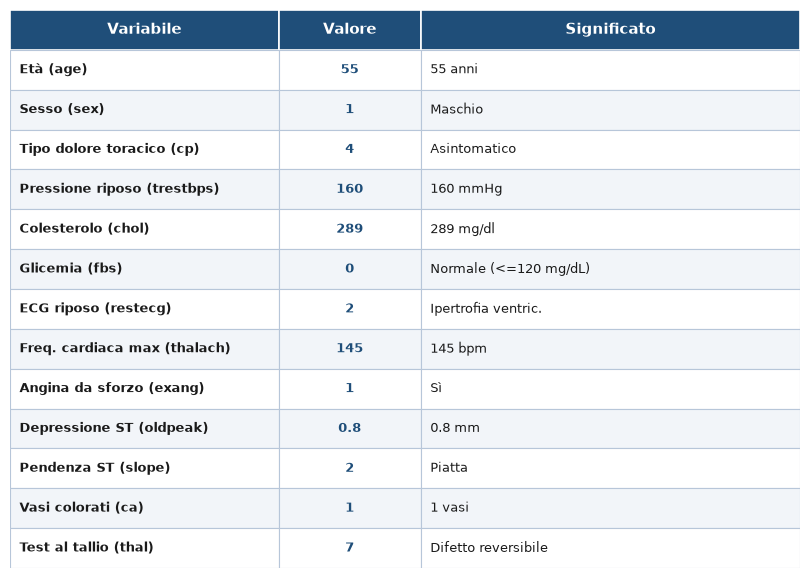

In [4]:
# --- QUI decido quali pazienti mi servono ---
pazienti_da_mostrare = [21, 24]

SALVA = False   # True = esporta i PNG in artifacts/, False = solo anteprima nel notebook

for idx in pazienti_da_mostrare:
    esito = "MALATO" if pred[idx] == 1 else "SANO"
    titolo = f"Paziente {idx}"
    percorso = ROOT / "artifacts" / "tabelle" / f"paziente_{idx}.png" if SALVA else None
    if percorso:
        percorso.parent.mkdir(parents=True, exist_ok=True)
    tabella_paziente(X_test, idx, titolo=titolo, salva=percorso)
    print(f"idx {idx:3d} | predetto {esito} | prob. malattia {proba[idx]:.2f} | reale {y_test.iloc[idx]}")

In [5]:
salva=percorso.with_suffix('.pdf') #per l'appendice della tesi

AttributeError: 'NoneType' object has no attribute 'with_suffix'

## 1. SHAP — attribuzioni locali

Waterfall plot: mostra come ogni feature spinge la predizione
dal valore base E[f(x)] verso l'output finale f(x).

In [6]:
import numpy as np

pred = model.predict(X_test)
indici_sani = np.where(pred == 0)[0]
print(indici_sani)

[ 1  2  3  4  7  9 10 14 16 17 19 20 22 23 27 28 31 32 33 35 39 41 42 46
 47 48 49 50 51 52 53 54 55 56 57]


In [7]:
import shap

explainer = shap.TreeExplainer(model)
expl = explainer(X_test)[:, :, 1]   # classe 1 = malattia

print(f"Valore base SHAP (prob. media malattia): {expl.base_values[0]:.3f}")

Valore base SHAP (prob. media malattia): 0.465


In [8]:
# # Paziente MALATO
# print("=== SHAP — paziente predetto MALATO ===")
# shap.plots.waterfall(expl[idx_malato], max_display=13)

In [9]:
# --- Mappa nomi feature (leggibili) ---
label_map = {
    'age':'Età', 'sex':'Sesso', 'cp':'Tipo dolore toracico',
    'trestbps':'Pressione a riposo', 'chol':'Colesterolo in mg/dL', 'fbs':'Glicemia a digiuno',
    'restecg':'ECG a riposo', 'thalach':'Freq. cardiaca max', 'exang':'Angina da sforzo',
    'oldpeak':'Depressione tratto ST', 'slope':'Pendenza tratto ST',
    'ca':'Vasi colorati', 'thal':'Test al tallio',
}

# --- Mappa valori per le sole variabili categoriche ---
# le continue (age, trestbps, chol, thalach, oldpeak) restano numeriche
value_maps = {
    'sex':     {0:'Femmina', 1:'Maschio'},
    'cp':      {1:'Angina tipica', 2:'Angina atipica', 3:'Dolore non anginoso', 4:'Asintomatico'},
    'fbs':     {0:'Normale (<=120 mg/dL)', 1:'Alta (>120 mg/dL)'},
    'restecg': {0:'Normale', 1:'Anomalia ST-T', 2:'Ipertrofia ventric.'},
    'exang':   {0:'No', 1:'Sì'},
    'slope':   {3:'Discendente', 2:'Piatta', 1:'Ascendente'},
    'thal':    {3:'Normale', 6:'Difetto fisso', 7:'Difetto reversibile'},
}

def crea_explanation_leggibile(expl_singolo, colonne_originali):
    """Ritorna una copia dell'Explanation con nomi feature e valori categorici tradotti.
    NON tocca .values: i contributi SHAP restano quelli calcolati sul modello reale."""
    e = expl_singolo
    e.feature_names = [label_map.get(c, c) for c in colonne_originali]
    nuovi_dati = []
    for c, v in zip(colonne_originali, e.data):
        if c in value_maps:
            nuovi_dati.append(value_maps[c].get(int(v), v))
        else:
            nuovi_dati.append(v)
    e.data = np.array(nuovi_dati, dtype=object)
    return e

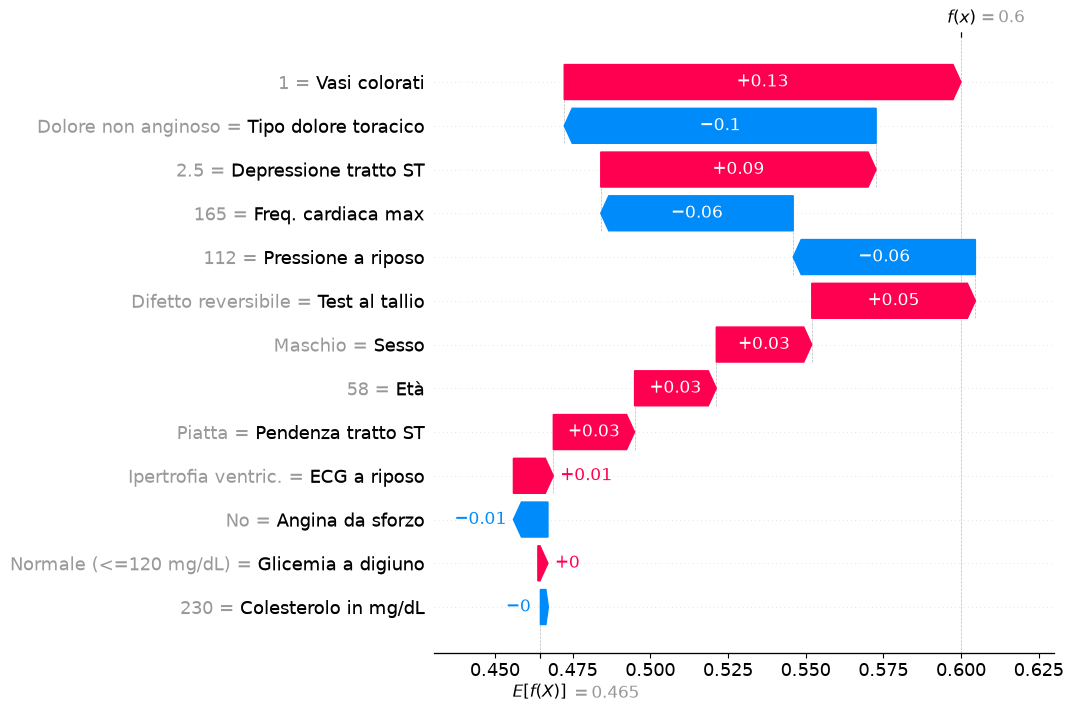

In [10]:
e_leggibile = crea_explanation_leggibile(expl[idx_malato], X_test.columns)
shap.plots.waterfall(e_leggibile, max_display=13)

=== SHAP — paziente predetto SANO ===


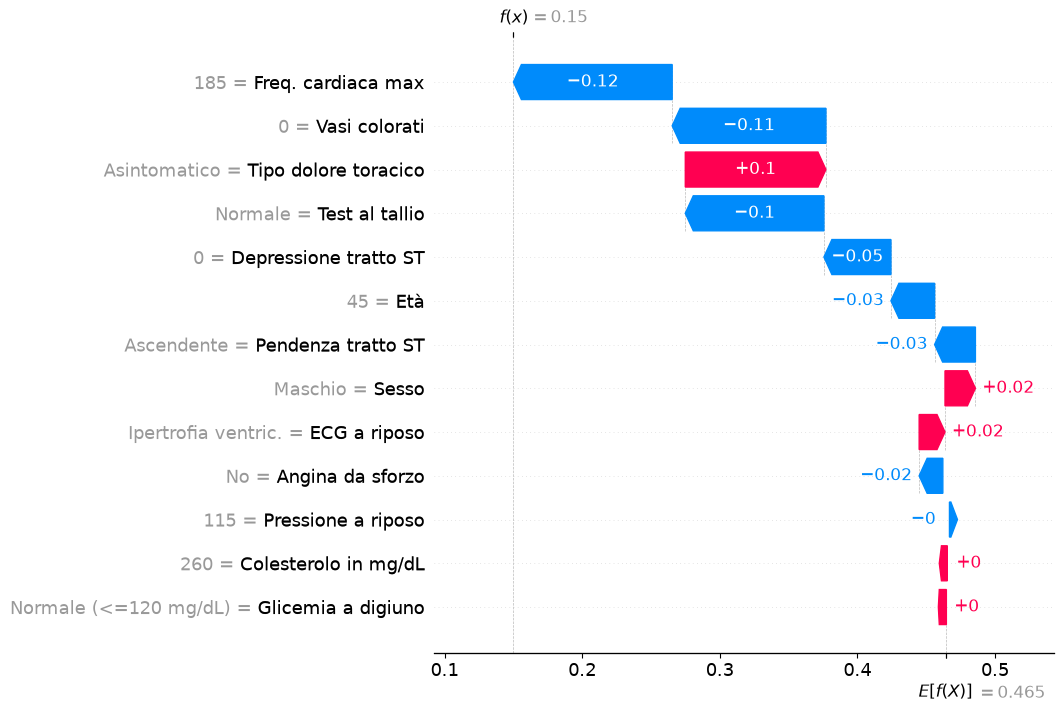

In [11]:
# Paziente SANO
print("=== SHAP — paziente predetto SANO ===")
e_leggibile = crea_explanation_leggibile(expl[idx_sano], X_test.columns)
shap.plots.waterfall(e_leggibile, max_display=13)

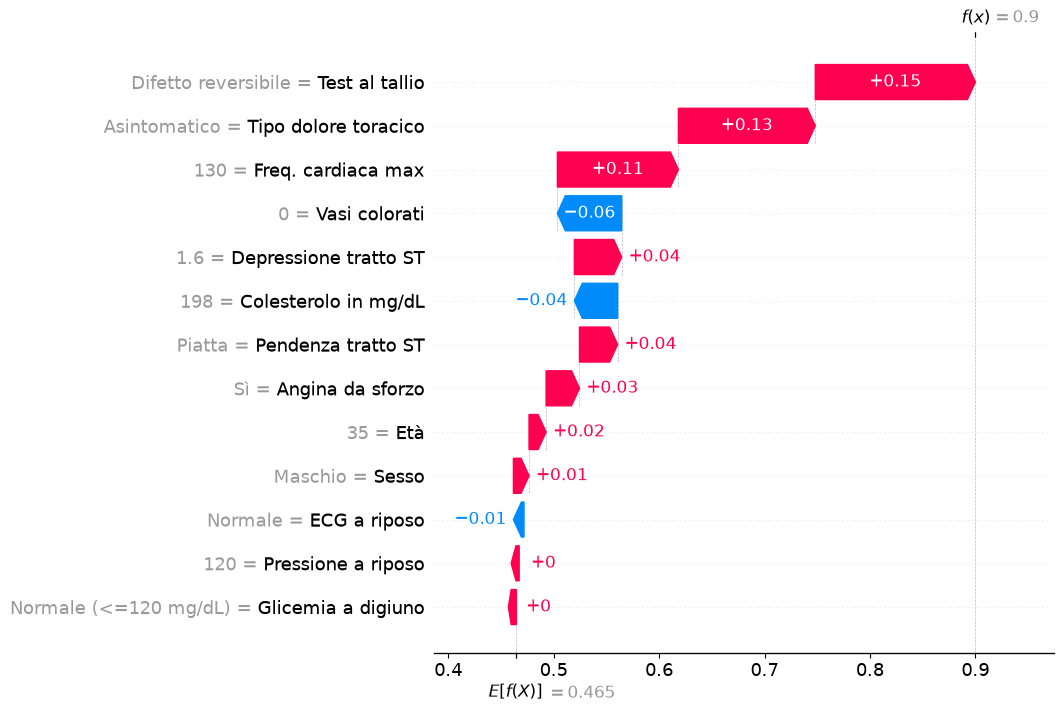

In [23]:
pazienti_da_mostrare = [36]  # scegli tu quali indici

for idx in pazienti_da_mostrare:
    e_leggibile = crea_explanation_leggibile(expl[idx], X_test.columns)
    shap.plots.waterfall(e_leggibile, max_display=13)

In [ ]:
import numpy as np

pred = model.predict(X_test)
indici_malati = np.where(pred == 1)[0]
print(indici_malati)

[ 2  3  6 13 14 15 16 17 18 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34
 37 39 41 45 46 47 48 49 50 52 53 57 59]


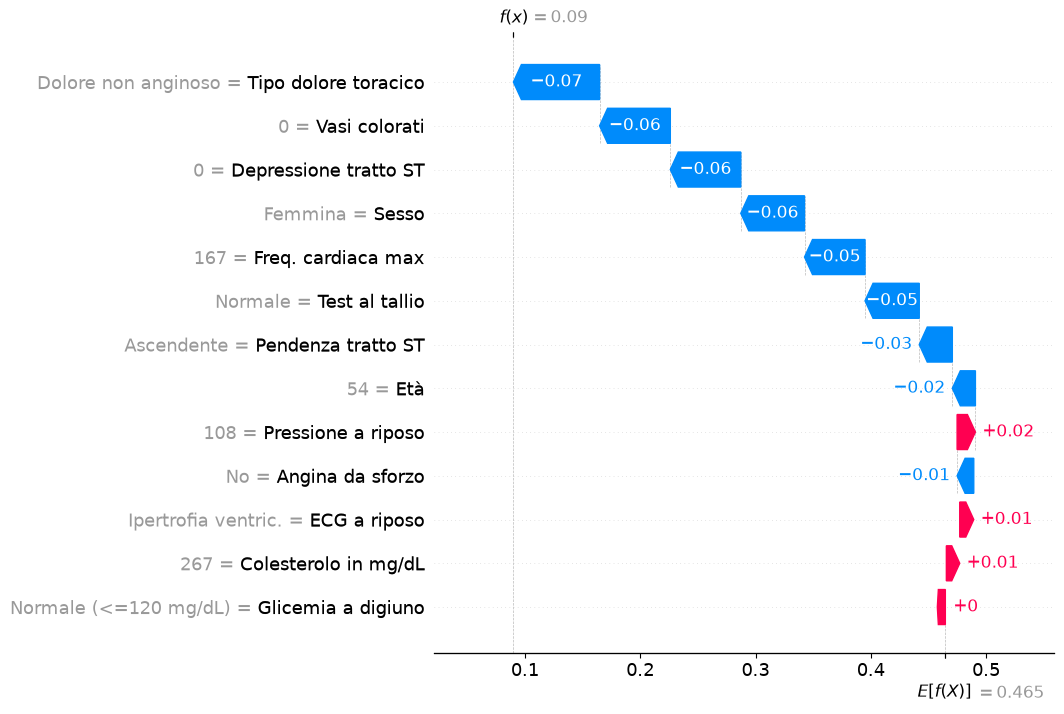

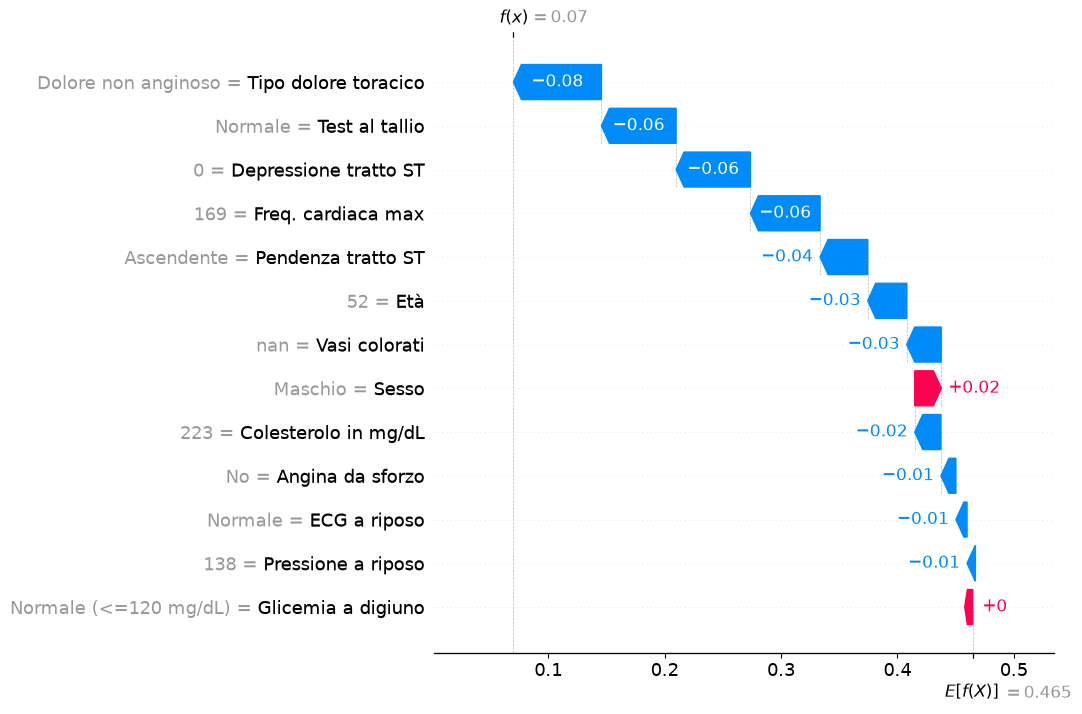

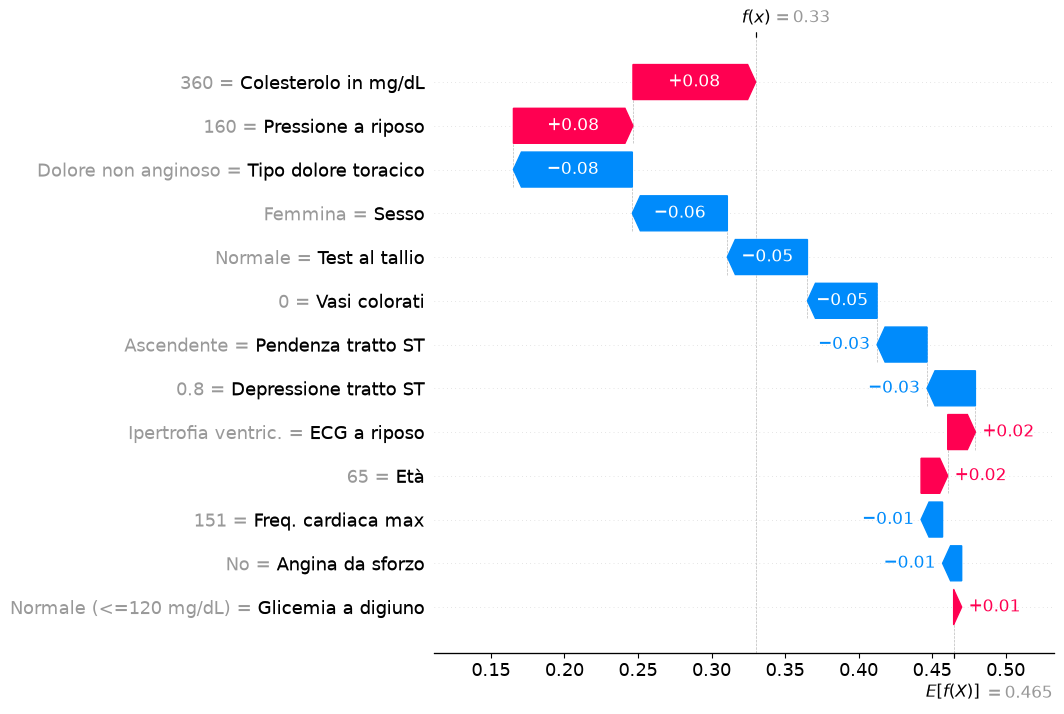

In [ ]:
pazienti_malati_da_mostrare = [32, 35, 39 ]  # scegli tu quali indici

for idx in pazienti_malati_da_mostrare:
    e_leggibile = crea_explanation_leggibile(expl[idx], X_test.columns)
    shap.plots.waterfall(e_leggibile, max_display=13)

=== SHAP — Beeswarm plot (intero test set) ===


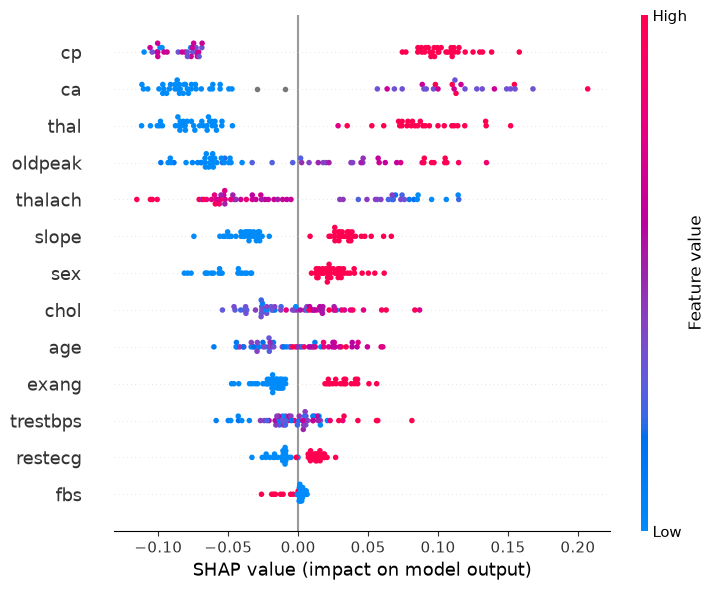

In [ ]:
# Beeswarm plot — distribuzione dei valori SHAP su tutti i campioni del test set
print("=== SHAP — Beeswarm plot (intero test set) ===")
shap.plots.beeswarm(expl, max_display=13)

=== SHAP — Bar plot (intero test set) ===


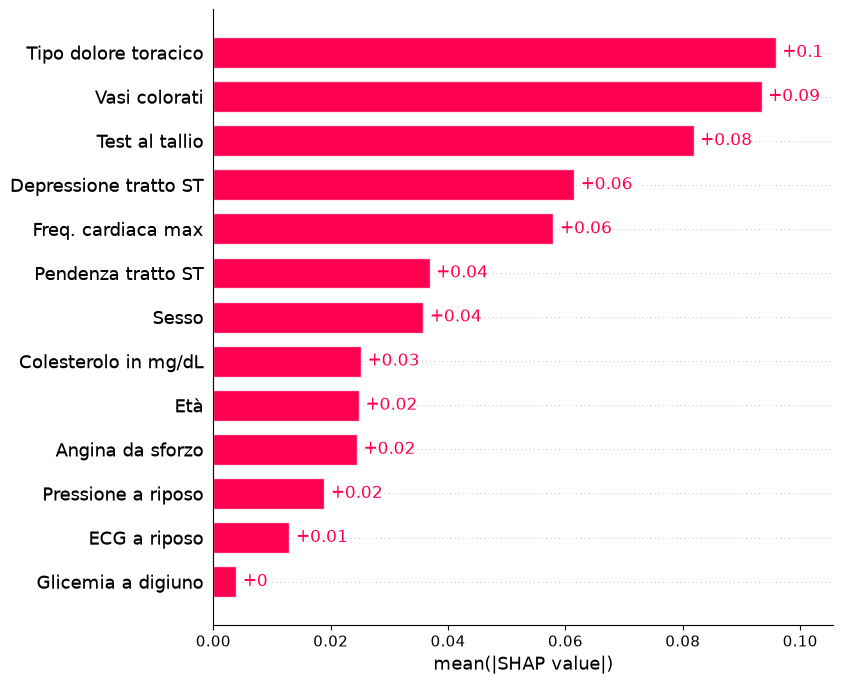

In [ ]:
# Bar plot — importanza media assoluta delle feature su tutto il test set
expl.feature_names = [label_map.get(c, c) for c in X_test.columns]

print("=== SHAP — Bar plot (intero test set) ===")
shap.plots.bar(expl, max_display=13)

## 2. DiCE — spiegazioni controfattuali

Risponde a: "cosa dovrebbe cambiare perché il modello cambi idea?"
Le feature non modificabili (age, sex) sono escluse dai controfattuali
per garantire azionabilità clinica.

In [ ]:
import dice_ml

cont_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
modifiable    = ["trestbps", "chol", "thalach", "oldpeak", "cp", "slope"]

# Fix compatibilità dice-ml / pandas: conversione colonna per colonna in float64
df_train = X_train.copy()
for col in df_train.columns:
    df_train[col] = df_train[col].astype("float64")
df_train["target"] = y_train.values.astype("float64")

d = dice_ml.Data(dataframe=df_train,
                 continuous_features=cont_features,
                 outcome_name="target")
m = dice_ml.Model(model=model, backend="sklearn")
# method="genetic": algoritmo evolutivo che ottimizza plausibilità e diversità
# dei controfattuali. Più lento di "random" ma produce risultati più realistici,
# adatti a essere mostrati a partecipanti non tecnici nello studio con gli utenti.
dice_exp = dice_ml.Dice(d, m, method="genetic")

In [ ]:
# Paziente MALATO
query_malato = X_test.iloc[[idx_malato]].copy()
for col in query_malato.columns:
    query_malato[col] = query_malato[col].astype("float64")

cf_malato = dice_exp.generate_counterfactuals(
    query_malato,
    total_CFs=3,
    desired_class="opposite",
    features_to_vary=modifiable,
)
cf_malato.visualize_as_dataframe(show_only_changes=True)

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:01<00:00,  1.39s/it]

Query instance (original outcome : 1)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,58.0,1.0,3.0,112.0,230.0,0.0,2.0,165.0,0.0,2.5,2.0,1.0,7.0,1



Diverse Counterfactual set (new outcome: 0)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,-,-,-,110.0,214.0,-,-,158.0,-,1.6,-,-,-,0.0
0,-,-,-,105.0,240.0,-,-,154.0,-,0.6,-,-,-,0.0
0,-,-,-,94.0,-,-,-,175.0,-,0.6,-,-,-,0.0


In [ ]:
# Paziente SANO
query_sano = X_test.iloc[[idx_sano]].copy()
for col in query_sano.columns:
    query_sano[col] = query_sano[col].astype("float64")

cf_sano = dice_exp.generate_counterfactuals(
    query_sano,
    total_CFs=3,
    desired_class="opposite",
    features_to_vary=modifiable,
)
cf_sano.visualize_as_dataframe(show_only_changes=True)

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  1.01it/s]

Query instance (original outcome : 0)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,45.0,1.0,4.0,115.0,260.0,0.0,2.0,185.0,0.0,0.0,1.0,0.0,3.0,0



Diverse Counterfactual set (new outcome: 1)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,-,-,-,94.0,141.0,-,-,71.0,-,-,-,-,-,-
0,-,-,3.0,108.0,243.0,-,-,152.0,-,-,-,-,-,1.0
0,-,-,-,110.0,141.0,-,-,71.0,-,0.6,2.0,-,-,1.0


## 3. Anchors — regole locali SE-ALLORA

Risponde a: "quale condizione minima basta a fissare questa predizione?"
- Precision: proporzione di casi nel vicinato in cui la regola è corretta
- Coverage: proporzione di input a cui la regola si applica

In [ ]:
from alibi.explainers import AnchorTabular

predict_fn = lambda x: model.predict(x)
anchor_exp = AnchorTabular(predict_fn, feature_names=list(X_train.columns))
anchor_exp.fit(X_train.values, disc_perc=(25, 50, 75))

AnchorTabular(meta={
  'name': 'AnchorTabular',
  'type': ['blackbox'],
  'explanations': ['local'],
  'params': {'seed': None, 'disc_perc': (25, 50, 75)}}
)

In [ ]:
# Paziente MALATO
a = anchor_exp.explain(X_test.iloc[idx_malato].values, threshold=0.95)
classe = int(predict_fn(X_test.iloc[[idx_malato]].values)[0])
print("=== Anchors — paziente predetto MALATO ===")
print("SE   " + "  E  ".join(a.anchor) if a.anchor else "(nessuna regola trovata)")
print(f"ALLORA predizione = {classe}  (1=malato)")
print(f"Precision: {a.precision:.2f}  |  Coverage: {a.coverage:.2f}")

=== Anchors — paziente predetto MALATO ===
SE   oldpeak > 1.60  E  slope > 1.00  E  age > 56.00  E  sex > 0.00  E  cp > 2.25  E  restecg > 0.00
ALLORA predizione = 1  (1=malato)
Precision: 0.96  |  Coverage: 0.48


In [ ]:
# Paziente SANO
a2 = anchor_exp.explain(X_test.iloc[idx_sano].values, threshold=0.95)
classe2 = int(predict_fn(X_test.iloc[[idx_sano]].values)[0])
print("=== Anchors — paziente predetto SANO ===")
print("SE   " + "  E  ".join(a2.anchor) if a2.anchor else "(nessuna regola trovata)")
print(f"ALLORA predizione = {classe2}  (0=sano)")
print(f"Precision: {a2.precision:.2f}  |  Coverage: {a2.coverage:.2f}")

=== Anchors — paziente predetto SANO ===
SE   oldpeak <= 0.00  E  thalach > 165.75  E  age <= 48.00  E  slope <= 1.00
ALLORA predizione = 0  (0=sano)
Precision: 0.96  |  Coverage: 0.26


In [ ]:
import sys; sys.path.insert(0, str(ROOT / "src"))
import stimoli_xai as sx

cont_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
modifiable    = ["trestbps", "chol", "thalach", "oldpeak"]

anchor_exp, predict_fn = sx.crea_spiegatore_anchors(model, X_train)
dice_exp = sx.crea_spiegatore_dice(model, X_train, y_train, cont_features)

print("Pazienti utilizzabili:", sx.pazienti_completi(X_test))

Pazienti utilizzabili: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 29 30 31 32 33 34 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50 51 52 53 54 55 56 57 58 59 60]


In [ ]:
import importlib; importlib.reload(sx)
print(hasattr(sx, "_testo_adattato"), hasattr(sx, "arrotonda_controfattuali"))

True True


In [ ]:
senza_eta_sesso = [c for c in X_test.columns if c not in ("age", "sex")]
indici = [1, 2, 3, 4, 5, 6, 7, 8]

prove = {
    "2 CF, tutte libere":    dict(modifiable="all", total_CFs=2, posthoc_sparsity_param=0.1),
    "1 CF, tutte libere":    dict(modifiable="all", total_CFs=1, posthoc_sparsity_param=0.1),
    "1 CF, sparsity 1.0":    dict(modifiable="all", total_CFs=1, posthoc_sparsity_param=1.0),
    "1 CF, senza età/sesso": dict(modifiable=senza_eta_sesso, total_CFs=1, posthoc_sparsity_param=1.0),
}

for nome, kw in prove.items():
    r = sx.genera_stimoli(indici=indici, X_test=X_test, model=model,
                          anchor_exp=anchor_exp, predict_fn=predict_fn, dice_exp=dice_exp,
                          cartella=ROOT / "artifacts" / "tmp", salva=False, verbose=False, **kw)
    f = r["feature_cambiate"]
    print(f"{nome:24s} -> mediana {f.median():.1f} | max {f.max()} | falliti {int(f.isna().sum())}")

100%|██████████| 1/1 [00:00<00:00,  1.97it/s]


2 CF, tutte libere       -> mediana 8.5 | max 9 | falliti 0


100%|██████████| 1/1 [00:00<00:00,  2.58it/s]


1 CF, tutte libere       -> mediana 8.0 | max 8 | falliti 0


100%|██████████| 1/1 [00:01<00:00,  1.33s/it]


1 CF, sparsity 1.0       -> mediana 7.5 | max 8 | falliti 0


100%|██████████| 1/1 [00:00<00:00,  2.73it/s]

1 CF, senza età/sesso    -> mediana 6.5 | max 7 | falliti 0


100%|██████████| 1/1 [00:05<00:00,  5.57s/it]


idx  45 | DiCE fallito: nessun controfattuale con <= 5 modifiche su 20 candidati
idx  45 | classe 1 | anchor 4 cond. (prec 0.95) | cf: None feature modificate


100%|██████████| 1/1 [02:12<00:00, 132.12s/it]


idx  58 | classe 1 | anchor 4 cond. (prec 0.97) | cf: 5 feature modificate


100%|██████████| 1/1 [00:04<00:00,  4.93s/it]


idx  59 | DiCE fallito: nessun controfattuale con <= 5 modifiche su 20 candidati
idx  59 | classe 1 | anchor 3 cond. (prec 1.00) | cf: None feature modificate


100%|██████████| 1/1 [00:05<00:00,  5.56s/it]

idx  60 | classe 1 | anchor 4 cond. (prec 1.00) | cf: 5 feature modificate


,idx,classe,feature_cambiate,quali
0,45,1,NaN,
1,58,1,5.0,"Età, Pressione a riposo, Colesterolo, Freq. ca..."
2,59,1,NaN,
3,60,1,5.0,"Età, Pressione a riposo, Colesterolo, Freq. ca..."


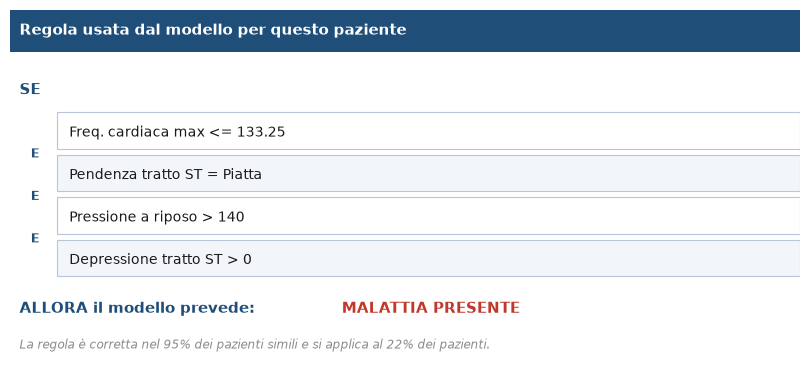

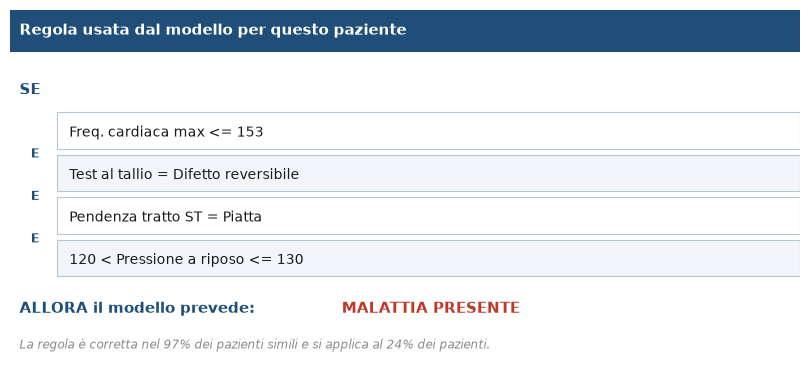

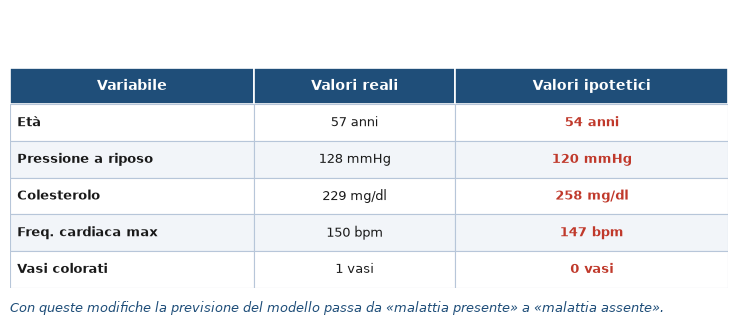

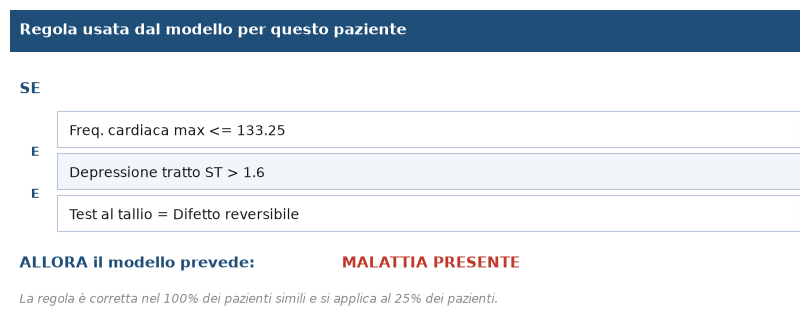

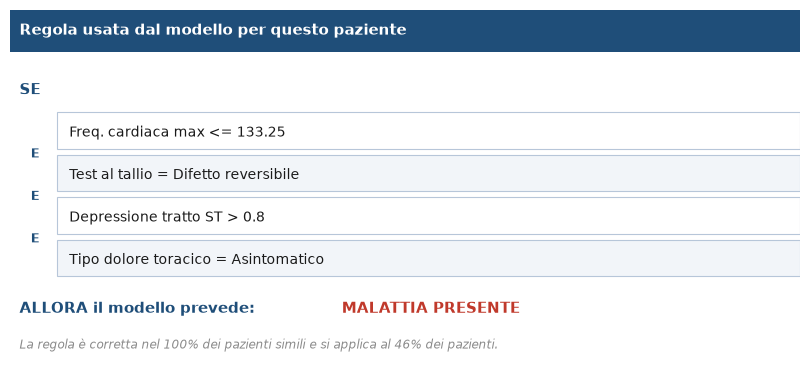

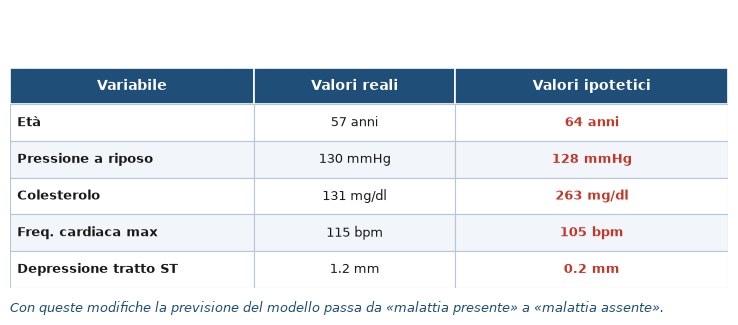

In [ ]:
riepilogo = sx.genera_stimoli(
    indici=[45, 58 , 59, 60],
    X_test=X_test, model=model,
    anchor_exp=anchor_exp, predict_fn=predict_fn, dice_exp=dice_exp,
    modifiable="all",
    cartella=ROOT / "artifacts" / "stimoli",
    total_CFs=2,            # scenari mostrati
    max_modifiche=5,        # tetto: max 5 variabili cambiate per scenario
    pool_CFs=20,            # candidati generati fra cui scegliere
    salva=True,
)
riepilogo[["idx", "classe", "feature_cambiate", "quali"]]

---
## Glossario

### Feature del dataset (Cleveland Heart Disease)

| Sigla / termine | Significato in italiano |
|---|---|
| `age` | Età del paziente (anni) |
| `sex` | Sesso — 1 = maschio, 0 = femmina |
| `cp` | Tipo di dolore toracico (*chest pain type*) — 0 = asintomatico, 1 = angina atipica, 2 = dolore non anginoso, 3 = angina tipica |
| `trestbps` | Pressione arteriosa a riposo (*resting blood pressure*), in mmHg |
| `chol` | Colesterolo sierico (*serum cholesterol*), in mg/dl |
| `fbs` | Glicemia a digiuno > 120 mg/dl (*fasting blood sugar*) — 1 = sì, 0 = no |
| `restecg` | Risultati dell'ECG a riposo (*resting electrocardiographic results*) — 0 = normale, 1 = anomalia onda ST-T, 2 = ipertrofia ventricolare sinistra |
| `thalach` | Frequenza cardiaca massima raggiunta durante il test da sforzo (*maximum heart rate achieved*) |
| `exang` | Angina indotta dall'esercizio (*exercise-induced angina*) — 1 = sì, 0 = no |
| `oldpeak` | Depressione del tratto ST indotta dall'esercizio rispetto al riposo (in mm) |
| `slope` | Pendenza del segmento ST al picco dell'esercizio — 0 = discendente, 1 = piatta, 2 = ascendente |
| `ca` | Numero di vasi coronarici principali visibili alla fluoroscopia (0–3) |
| `thal` | Talassemia / perfusione miocardica — 1 = normale, 2 = difetto fisso, 3 = difetto reversibile |

